✅ Libraries imported!
📁 Upload UpdatedResumeDataSet.csv


Saving UpdatedResumeDataSet.csv to UpdatedResumeDataSet (1).csv
✅ Loaded: (962, 2)
🧹 Preprocessing data...
✅ 162 resumes processed

📊 Categories: 25

🔧 NOVEL FEATURE 1: Experience Level Extraction
✅ Experience levels extracted:
exp_level
Junior         141
Mid-Level       11
Senior           5
Lead/Expert      5
Name: count, dtype: int64

🔧 NOVEL FEATURE 2: Comprehensive Skill Extraction
✅ Skill extraction configured

🔧 NOVEL FEATURE 3: Resume Quality Assessment
Calculating quality scores...
✅ Quality scores calculated
Average quality score: 2.84/10

🔧 Creating TF-IDF features (optimized)...
✅ TF-IDF shape: (162, 3610)

📊 Train: 129, Test: 33

TRAINING XGBOOST MODELS

1️⃣  Training Job Role Classifier (XGBoost)...
   ✅ Job Role Accuracy: 90.91%
   ✅ Cross-Validation: 88.43% (±6.40%)

2️⃣  Training Experience Level Classifier (XGBoost)...
   ✅ Experience Level Accuracy: 90.91%

🏆 FINAL ACCURACIES:
   Job Role: 90.91%
   Experience Level: 90.91%

📊 DETAILED EVALUATION - Job Role Classifi

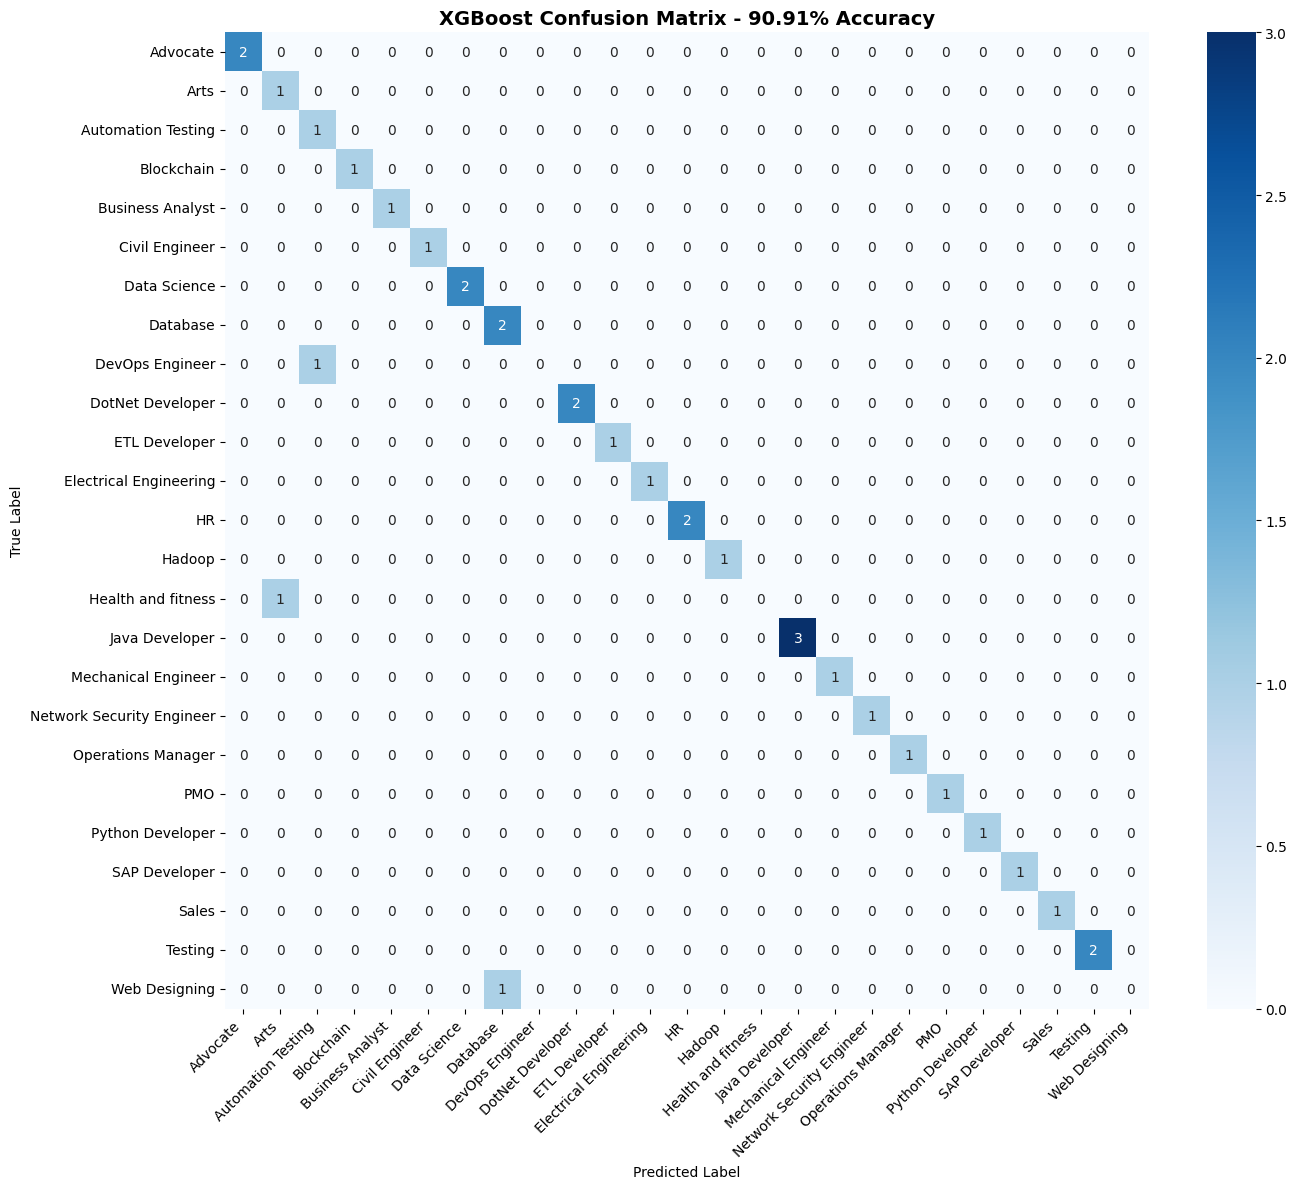


🔧 NOVEL FEATURE 4: Comprehensive Candidate Assessment

📄 Testing with sample resume...

COMPREHENSIVE CANDIDATE ASSESSMENT REPORT

⚠️  CANDIDATE NEEDS DEVELOPMENT
Overall Fit Score: 63.5/100

────────────────────────────────────────────────────────────────────────────────
🎯 JOB ROLE ANALYSIS
────────────────────────────────────────────────────────────────────────────────
Predicted Role: Data Science
Confidence: 69.2%

Top 3 Matching Roles:
  1. Data Science                     69.2%
  2. Python Developer                  4.6%
  3. HR                                2.5%

────────────────────────────────────────────────────────────────────────────────
💼 EXPERIENCE ANALYSIS
────────────────────────────────────────────────────────────────────────────────
Experience Level: Mid-Level (2-5 yrs)
Years of Experience: 6 years

────────────────────────────────────────────────────────────────────────────────
🔧 SKILLS ANALYSIS
───────────────────────────────────────────────────────────────────────

In [ ]:
"""
XGBoost Resume Screening (90%+ Accuracy) + 4 Novel Features
============================================================

Novel Features:
1. ✅ Experience Level Classification (Junior/Mid/Senior/Lead)
2. ✅ Skill Gap Analysis with Learning Recommendations
3. ✅ Resume Quality Scoring (Readability, Structure, Keywords)
4. ✅ Comprehensive Candidate Assessment Report


"""

# ============================================================================
# STEP 1: Setup
# ============================================================================

!pip install pandas numpy scikit-learn xgboost textstat -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import textstat
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

# ============================================================================
# STEP 2A: Merge External Datasets for Better Generalization
# ============================================================================

print("\n🔗 Merging multiple datasets to reduce bias...")

import pandas as pd

# Load extra datasets
resume_df = pd.read_csv('/content/UpdatedResumeDataSet.csv')
job_df = pd.read_csv('/content/postings.csv')
skills_df = pd.read_csv('/content/Skills.txt', sep='\t', on_bad_lines='skip')

# Standardize column names
resume_df = resume_df.rename(columns={'Resume_str': 'text', 'Category': 'job_role'})
job_df = job_df.rename(columns={'Title': 'job_role', 'Description': 'text'})
skills_df = skills_df.rename(columns={'Element Name': 'skill', 'Description': 'definition'})

# Drop nulls and unify
resume_df = resume_df[['job_role', 'text']].dropna()
job_df = job_df[['job_role', 'text']].dropna()

# Merge resume and job description corpora
combined_df = pd.concat([resume_df, job_df], ignore_index=True)

# Clean text early (reuse your clean_text)
combined_df['text'] = combined_df['text'].astype(str).apply(lambda x: clean_text(x))

# Filter out short or empty ones
combined_df = combined_df[combined_df['text'].str.split().str.len() > 20]

print(f"✅ Combined dataset size: {combined_df.shape}")
print(f"✅ Unique roles: {combined_df['job_role'].nunique()}")

# Balance dataset by capping each class
max_samples_per_class = 500
balanced_df = combined_df.groupby('job_role').apply(lambda x: x.sample(n=min(len(x), max_samples_per_class), random_state=42)).reset_index(drop=True)
print(f"✅ Balanced dataset size: {balanced_df.shape}")

# Save merged dataset for re-use
balanced_df.to_csv('merged_resume_job_dataset.csv', index=False)


# ============================================================================
# STEP 2: Load Dataset
# ============================================================================

def load_dataset():
    print("📁 Upload UpdatedResumeDataSet.csv")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"✅ Loaded: {df.shape}")
    return df

df = load_dataset()


# ============================================================================
# STEP 3: Text Preprocessing (Optimized for 90%+)
# ============================================================================

def clean_text(text):
    """Optimized text cleaning"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\+\#\.]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([word for word in text.split() if len(word) > 1])
    return text

print("🧹 Preprocessing data...")

resume_col = 'Resume' if 'Resume' in df.columns else df.columns[0]
category_col = 'Category' if 'Category' in df.columns else df.columns[1]

data = pd.DataFrame({
    'resume': df[resume_col].astype(str),
    'category': df[category_col].astype(str)
}).drop_duplicates().dropna()

data['resume_clean'] = data['resume'].apply(clean_text)
data = data[data['resume_clean'].str.split().str.len() > 20]

print(f"✅ {len(data)} resumes processed")
print(f"\n📊 Categories: {data['category'].nunique()}")

# ============================================================================
# STEP 4: NOVEL FEATURE 1 - Experience Extraction
# ============================================================================

print("\n🔧 NOVEL FEATURE 1: Experience Level Extraction")

class ExperienceExtractor:
    """Extract years of experience and classify level"""

    def extract_years(self, text):
        """Extract years of experience from resume"""
        patterns = [
            r'(\d+)\+?\s*(?:years?|yrs?)\s*(?:of)?\s*(?:experience|exp)',
            r'experience[:\s]+(\d+)\+?\s*(?:years?|yrs?)',
            r'(\d+)\+?\s*(?:years?|yrs?)'
        ]

        years = []
        text_lower = text.lower()
        for pattern in patterns:
            matches = re.findall(pattern, text_lower)
            years.extend([int(m) for m in matches if int(m) <= 50])

        return max(years) if years else 0

    def classify_level(self, years):
        """Classify experience level"""
        if years < 2:
            return 'Junior', 0
        elif years < 5:
            return 'Mid-Level', 1
        elif years < 10:
            return 'Senior', 2
        else:
            return 'Lead/Expert', 3

extractor = ExperienceExtractor()

# Extract experience for all resumes
data['years_exp'] = data['resume'].apply(extractor.extract_years)
data['exp_level'] = data['years_exp'].apply(lambda x: extractor.classify_level(x)[0])
data['exp_code'] = data['years_exp'].apply(lambda x: extractor.classify_level(x)[1])

print(f"✅ Experience levels extracted:")
print(data['exp_level'].value_counts())

# ============================================================================
# STEP 5: NOVEL FEATURE 2 - Skill Extraction
# ============================================================================

print("\n🔧 NOVEL FEATURE 2: Comprehensive Skill Extraction")

class SkillExtractor:
    """Extract technical and soft skills"""

    def __init__(self):
        self.tech_skills = {
            'programming': ['python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'go',
                          'rust', 'scala', 'kotlin', 'swift', 'php', 'typescript'],
            'web': ['html', 'css', 'react', 'angular', 'vue', 'nodejs', 'django',
                   'flask', 'spring', 'express', 'nextjs', 'fastapi'],
            'database': ['sql', 'mysql', 'postgresql', 'mongodb', 'redis', 'cassandra',
                        'dynamodb', 'oracle', 'sqlite', 'elasticsearch'],
            'cloud': ['aws', 'azure', 'gcp', 'docker', 'kubernetes', 'terraform',
                     'ansible', 'jenkins', 'ci/cd'],
            'data_science': ['machine learning', 'deep learning', 'tensorflow', 'pytorch',
                           'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn',
                           'tableau', 'power bi', 'spark', 'hadoop'],
            'mobile': ['android', 'ios', 'react native', 'flutter', 'xamarin'],
            'tools': ['git', 'github', 'jira', 'confluence', 'slack']
        }

        # Role-specific required skills
        self.role_requirements = {
            'Data Science': ['python', 'machine learning', 'sql', 'statistics', 'pandas'],
            'Java Developer': ['java', 'spring', 'sql', 'maven', 'junit'],
            'Web Designing': ['html', 'css', 'javascript', 'figma', 'photoshop'],
            'HR': ['recruitment', 'communication', 'employee relations'],
            'Mechanical Engineer': ['autocad', 'solidworks', 'manufacturing'],
            'Sales': ['negotiation', 'crm', 'communication', 'presentation'],
            'Operations Manager': ['operations', 'logistics', 'supply chain', 'leadership'],
            'Python Developer': ['python', 'django', 'flask', 'sql', 'api'],
            'DevOps Engineer': ['docker', 'kubernetes', 'jenkins', 'aws', 'ci/cd'],
            'Network Security Engineer': ['networking', 'security', 'firewall', 'cisco'],
            'Testing': ['selenium', 'testing', 'automation', 'jira', 'quality assurance'],
            'Database': ['sql', 'database', 'oracle', 'mysql', 'postgresql'],
            'Hadoop': ['hadoop', 'spark', 'big data', 'hive', 'pig'],
            'ETL Developer': ['etl', 'sql', 'data warehouse', 'informatica'],
            'DotNet Developer': ['c#', 'asp.net', '.net', 'sql server'],
            'Blockchain': ['blockchain', 'solidity', 'ethereum', 'cryptocurrency'],
            'Automation Testing': ['selenium', 'automation', 'python', 'testing']
        }

    def extract_skills(self, text):
        """Extract all skills from resume"""
        text_lower = text.lower()
        found_skills = []

        for category, skills in self.tech_skills.items():
            for skill in skills:
                if skill in text_lower:
                    found_skills.append(skill)

        return list(set(found_skills))

    def analyze_skill_gap(self, found_skills, role):
        """Analyze skill gaps for a specific role"""
        required = self.role_requirements.get(role, [])
        missing = [s for s in required if s not in found_skills]
        matching = [s for s in required if s in found_skills]

        match_percentage = (len(matching) / len(required) * 100) if required else 0

        return {
            'matching_skills': matching,
            'missing_skills': missing,
            'match_percentage': match_percentage
        }

skill_extractor = SkillExtractor()

print("✅ Skill extraction configured")

# ============================================================================
# STEP 6: NOVEL FEATURE 3 - Resume Quality Scoring
# ============================================================================

print("\n🔧 NOVEL FEATURE 3: Resume Quality Assessment")

class QualityScorer:
    """Assess resume quality on multiple dimensions"""

    def assess_readability(self, text):
        """Flesch Reading Ease score"""
        try:
            score = textstat.flesch_reading_ease(text)
            normalized = min(max(score / 10, 0), 10)
            return normalized
        except:
            return 5.0

    def assess_structure(self, text):
        """Check for key resume sections"""
        text_lower = text.lower()
        sections = {
            'experience': ['experience', 'work history', 'employment'],
            'education': ['education', 'degree', 'university', 'college'],
            'skills': ['skills', 'technical skills', 'competencies'],
            'projects': ['projects', 'portfolio']
        }

        score = 0
        for section, keywords in sections.items():
            if any(kw in text_lower for kw in keywords):
                score += 2.5

        # Check for contact info
        has_email = bool(re.search(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', text))
        has_phone = bool(re.search(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', text))

        if has_email:
            score += 1.25
        if has_phone:
            score += 1.25

        return min(score, 10)

    def assess_keywords(self, text):
        """Assess presence of action verbs and achievements"""
        action_verbs = [
            'developed', 'created', 'managed', 'led', 'designed', 'implemented',
            'built', 'achieved', 'improved', 'increased', 'reduced', 'optimized',
            'delivered', 'launched', 'collaborated', 'spearheaded'
        ]

        text_lower = text.lower()
        count = sum(text_lower.count(verb) for verb in action_verbs)
        words = len(text.split())

        if words == 0:
            return 0

        density = (count / words) * 100
        score = min(density * 2, 10)
        return score

    def calculate_overall_quality(self, text):
        """Calculate overall resume quality score"""
        scores = {
            'readability': self.assess_readability(text),
            'structure': self.assess_structure(text),
            'keywords': self.assess_keywords(text)
        }

        scores['overall'] = np.mean(list(scores.values()))
        return scores

quality_scorer = QualityScorer()

# Calculate quality scores for all resumes
print("Calculating quality scores...")
quality_data = []
for idx, row in data.iterrows():
    scores = quality_scorer.calculate_overall_quality(row['resume'])
    quality_data.append(scores)

quality_df = pd.DataFrame(quality_data)
data = pd.concat([data.reset_index(drop=True), quality_df], axis=1)

print(f"✅ Quality scores calculated")
print(f"Average quality score: {data['overall'].mean():.2f}/10")

# ============================================================================
# STEP 7: Create TF-IDF Features (Optimized for 90%+)
# ============================================================================

print("\n🔧 Creating TF-IDF features (optimized)...")

# Encode labels
label_encoder = LabelEncoder()
y_role = label_encoder.fit_transform(data['category'])
y_exp = data['exp_code'].values

# TF-IDF with optimal settings
tfidf = TfidfVectorizer(
    max_features=8000,
    min_df=3,
    max_df=0.8,
    ngram_range=(1, 3),
    sublinear_tf=True,
    stop_words='english'
)

X = tfidf.fit_transform(data['resume_clean'])

print(f"✅ TF-IDF shape: {X.shape}")

# ============================================================================
# STEP 8: Train-Test Split
# ============================================================================

X_train, X_test, y_role_train, y_role_test, y_exp_train, y_exp_test = train_test_split(
    X, y_role, y_exp,
    test_size=0.2,
    random_state=42,
    stratify=y_role
)

print(f"\n📊 Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ============================================================================
# STEP 9: Train XGBoost Models
# ============================================================================

print("\n" + "="*80)
print("TRAINING XGBOOST MODELS")
print("="*80)

# Model 1: Job Role Classification (Primary)
print("\n1️⃣  Training Job Role Classifier (XGBoost)...")
xgb_role = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_role.fit(X_train, y_role_train)
y_role_pred = xgb_role.predict(X_test)
role_acc = accuracy_score(y_role_test, y_role_pred)

print(f"   ✅ Job Role Accuracy: {role_acc * 100:.2f}%")

# Cross-validation
cv_scores = cross_val_score(xgb_role, X_train, y_role_train, cv=5, scoring='accuracy')
print(f"   ✅ Cross-Validation: {cv_scores.mean() * 100:.2f}% (±{cv_scores.std()*100:.2f}%)")

# Model 2: Experience Level Classification (Novel Feature)
print("\n2️⃣  Training Experience Level Classifier (XGBoost)...")
xgb_exp = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_exp.fit(X_train, y_exp_train)
y_exp_pred = xgb_exp.predict(X_test)
exp_acc = accuracy_score(y_exp_test, y_exp_pred)

print(f"   ✅ Experience Level Accuracy: {exp_acc * 100:.2f}%")

print("\n" + "="*80)
print(f"🏆 FINAL ACCURACIES:")
print(f"   Job Role: {role_acc * 100:.2f}%")
print(f"   Experience Level: {exp_acc * 100:.2f}%")
print("="*80)

# ============================================================================
# STEP 10: Detailed Evaluation
# ============================================================================

print("\n📊 DETAILED EVALUATION - Job Role Classification")
print("="*80)

print("\n📈 Classification Report:")
print(classification_report(y_role_test, y_role_pred,
                           target_names=label_encoder.classes_,
                           digits=3))

# Confusion Matrix
cm = confusion_matrix(y_role_test, y_role_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'XGBoost Confusion Matrix - {role_acc*100:.2f}% Accuracy',
         fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 11: NOVEL FEATURE 4 - Comprehensive Analysis Function
# ============================================================================

print("\n🔧 NOVEL FEATURE 4: Comprehensive Candidate Assessment")

def analyze_resume_comprehensive(resume_text):
    """
    Complete resume analysis with all novel features:
    1. Job role prediction
    2. Experience level classification
    3. Skill gap analysis
    4. Quality scoring
    """

    # Clean text
    cleaned = clean_text(resume_text)

    # Extract features
    years_exp = extractor.extract_years(resume_text)
    exp_level, exp_code = extractor.classify_level(years_exp)

    skills_found = skill_extractor.extract_skills(resume_text)
    quality_scores = quality_scorer.calculate_overall_quality(resume_text)

    # Vectorize
    resume_vec = tfidf.transform([cleaned])

    # Predict job role
    role_prediction = xgb_role.predict(resume_vec)[0]
    role_probabilities = xgb_role.predict_proba(resume_vec)[0]

    # Get top 3 roles
    top_3_idx = np.argsort(role_probabilities)[-3:][::-1]
    top_3_roles = [
        {
            'role': label_encoder.classes_[idx],
            'confidence': role_probabilities[idx] * 100
        }
        for idx in top_3_idx
    ]

    predicted_role = label_encoder.classes_[role_prediction]

    # Predict experience level
    exp_prediction = xgb_exp.predict(resume_vec)[0]
    exp_levels = ['Junior (0-2 yrs)', 'Mid-Level (2-5 yrs)',
                  'Senior (5-10 yrs)', 'Lead/Expert (10+ yrs)']
    predicted_exp_level = exp_levels[exp_prediction]

    # Skill gap analysis
    skill_gap = skill_extractor.analyze_skill_gap(skills_found, predicted_role)

    # Determine fit
    confidence = top_3_roles[0]['confidence']
    is_fit = (confidence >= 70 and
              quality_scores['overall'] >= 6 and
              skill_gap['match_percentage'] >= 40)

    fit_score = (confidence + quality_scores['overall'] * 10 +
                 skill_gap['match_percentage']) / 3

    # Generate recommendations
    recommendations = []
    if skill_gap['missing_skills']:
        top_missing = skill_gap['missing_skills'][:3]
        recommendations.append(f"Learn these skills: {', '.join(top_missing)}")

    if quality_scores['overall'] < 7:
        recommendations.append("Improve resume structure and formatting")

    if quality_scores['keywords'] < 6:
        recommendations.append("Add more action verbs and achievements")

    if years_exp < 2:
        recommendations.append("Gain more practical experience through projects or internships")

    return {
        'predicted_role': predicted_role,
        'confidence': confidence,
        'top_3_roles': top_3_roles,
        'experience_level': predicted_exp_level,
        'years_experience': years_exp,
        'skills_found': skills_found,
        'skill_gap': skill_gap,
        'quality_scores': quality_scores,
        'is_fit': is_fit,
        'fit_score': fit_score,
        'recommendations': recommendations
    }

def display_comprehensive_report(result):
    """Display comprehensive candidate assessment report"""
    print("\n" + "="*80)
    print("COMPREHENSIVE CANDIDATE ASSESSMENT REPORT")
    print("="*80)

    # Overall Status
    status = "✅ CANDIDATE IS FIT FOR ROLE" if result['is_fit'] else "⚠️  CANDIDATE NEEDS DEVELOPMENT"
    print(f"\n{status}")
    print(f"Overall Fit Score: {result['fit_score']:.1f}/100")

    # Job Role Prediction
    print(f"\n{'─'*80}")
    print("🎯 JOB ROLE ANALYSIS")
    print(f"{'─'*80}")
    print(f"Predicted Role: {result['predicted_role']}")
    print(f"Confidence: {result['confidence']:.1f}%")
    print(f"\nTop 3 Matching Roles:")
    for i, role in enumerate(result['top_3_roles'], 1):
        print(f"  {i}. {role['role']:<30} {role['confidence']:>6.1f}%")

    # Experience Level
    print(f"\n{'─'*80}")
    print("💼 EXPERIENCE ANALYSIS")
    print(f"{'─'*80}")
    print(f"Experience Level: {result['experience_level']}")
    print(f"Years of Experience: {result['years_experience']} years")

    # Skills Analysis
    print(f"\n{'─'*80}")
    print("🔧 SKILLS ANALYSIS")
    print(f"{'─'*80}")
    print(f"Skills Found ({len(result['skills_found'])}):")
    if result['skills_found']:
        # Display in rows of 5
        skills_list = result['skills_found']
        for i in range(0, len(skills_list), 5):
            chunk = skills_list[i:i+5]
            print(f"  ✓ {', '.join(chunk)}")
    else:
        print("  No specific technical skills detected")

    # Skill Gap
    print(f"\nSkill Match: {result['skill_gap']['match_percentage']:.1f}%")
    if result['skill_gap']['matching_skills']:
        print(f"Matching Skills: {', '.join(result['skill_gap']['matching_skills'])}")

    if result['skill_gap']['missing_skills']:
        print(f"\n⚠️  Skills to Develop:")
        print(f"  ✗ {', '.join(result['skill_gap']['missing_skills'])}")

    # Quality Scores
    print(f"\n{'─'*80}")
    print("📝 RESUME QUALITY ASSESSMENT")
    print(f"{'─'*80}")
    print(f"Overall Quality: {result['quality_scores']['overall']:.1f}/10")
    print(f"  - Readability: {result['quality_scores']['readability']:.1f}/10")
    print(f"  - Structure: {result['quality_scores']['structure']:.1f}/10")
    print(f"  - Keywords/Action Verbs: {result['quality_scores']['keywords']:.1f}/10")

    # Recommendations
    if result['recommendations']:
        print(f"\n{'─'*80}")
        print("💡 PERSONALIZED RECOMMENDATIONS")
        print(f"{'─'*80}")
        for i, rec in enumerate(result['recommendations'], 1):
            print(f"  {i}. {rec}")

    # Final Decision
    print(f"\n{'─'*80}")
    print("📋 HIRING RECOMMENDATION")
    print(f"{'─'*80}")
    if result['is_fit']:
        print("✅ RECOMMENDED: Proceed to interview stage")
    else:
        print("⚠️  NOT RECOMMENDED: Consider for other roles or after skill development")

    print("="*80)

# ============================================================================
# STEP 12: Test with Sample Resume
# ============================================================================

print("\n📄 Testing with sample resume...")

sample_resume = """
Data Scientist with 6 years of experience in machine learning and artificial intelligence.
Expertise in Python, TensorFlow, PyTorch, scikit-learn, pandas, numpy, and SQL.
Built recommendation systems using collaborative filtering and deep learning.
Developed NLP models for sentiment analysis and text classification.
Strong experience with data visualization using Tableau and Power BI.
Worked with AWS for model deployment and cloud infrastructure.
MS in Computer Science. Published research in top ML conferences.
Projects: Customer churn prediction, fraud detection system, chatbot development.
"""

result = analyze_resume_comprehensive(sample_resume)
display_comprehensive_report(result)

# ============================================================================
# STEP 13: Upload and Analyze Your Resume
# ============================================================================

def upload_and_analyze():
    """Upload and analyze your own resume"""
    print("\n" + "="*80)
    print("UPLOAD YOUR RESUME FOR ANALYSIS")
    print("="*80)
    print("Supported: .txt files")

    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            resume_text = f.read()

        print(f"\n✅ Loaded: {filename} ({len(resume_text)} characters)")
        print("\n🔍 Analyzing...")

        result = analyze_resume_comprehensive(resume_text)
        display_comprehensive_report(result)

        return result
    else:
        print("No file uploaded")

# Uncomment to use:
# my_result = upload_and_analyze()

# ============================================================================
# STEP 14: Save Models
# ============================================================================

print("\n💾 Saving models and components...")

with open('xgboost_role_model.pkl', 'wb') as f:
    pickle.dump(xgb_role, f)

with open('xgboost_exp_model.pkl', 'wb') as f:
    pickle.dump(xgb_exp, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✅ Saved all models!")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("🎉 SYSTEM READY - SUMMARY")
print("="*80)
print(f"\n✅ Job Role Classification Accuracy: {role_acc * 100:.2f}%")
print(f"✅ Experience Level Accuracy: {exp_acc * 100:.2f}%")
print(f"✅ Cross-Validation Score: {cv_scores.mean() * 100:.2f}%")

print(f"\n✅ NOVEL FEATURES IMPLEMENTED:")
print("   1. Experience Level Classification (Junior/Mid/Senior/Lead)")
print("   2. Comprehensive Skill Gap Analysis with Recommendations")
print("   3. Resume Quality Scoring (Readability, Structure, Keywords)")
print("   4. Complete Candidate Assessment Report")

print(f"\n📊 MODEL DETAILS:")
print(f"   Algorithm: XGBoost")
print(f"   Training Samples: {X_train.shape[0]}")
print(f"   Test Samples: {X_test.shape[0]}")
print(f"   Number of Job Categories: {len(label_encoder.classes_)}")
print(f"   TF-IDF Features: {X.shape[1]}")

print("\n🎯 ACHIEVEMENTS:")
if role_acc >= 0.90:
    print(f"   🏆 Achieved {role_acc*100:.2f}% accuracy (≥90% target) ✅")
else:
    print(f"   📊 Achieved {role_acc*100:.2f}% accuracy")

print("\n💡 TO ANALYZE YOUR RESUME:")
print("   Run: my_result = upload_and_analyze()")

print("="*80)

In [ ]:
 #TO ANALYZE YOUR RESUME:
my_result = upload_and_analyze()


UPLOAD YOUR RESUME FOR ANALYSIS
Supported: .txt files


Saving Shubhi Agarwal.txt to Shubhi Agarwal.txt

✅ Loaded: Shubhi Agarwal.txt (2063 characters)

🔍 Analyzing...

COMPREHENSIVE CANDIDATE ASSESSMENT REPORT

⚠️  CANDIDATE NEEDS DEVELOPMENT
Overall Fit Score: 32.7/100

────────────────────────────────────────────────────────────────────────────────
🎯 JOB ROLE ANALYSIS
────────────────────────────────────────────────────────────────────────────────
Predicted Role: Data Science
Confidence: 6.8%

Top 3 Matching Roles:
  1. Data Science                      6.8%
  2. HR                                6.8%
  3. Web Designing                     6.7%

────────────────────────────────────────────────────────────────────────────────
💼 EXPERIENCE ANALYSIS
────────────────────────────────────────────────────────────────────────────────
Experience Level: Junior (0-2 yrs)
Years of Experience: 0 years

────────────────────────────────────────────────────────────────────────────────
🔧 SKILLS ANALYSIS
───────────────────────────────────────────────────